# Previsão da quantidade de feridos em Sinistros de Trânsito nas rodovias Brasileiras

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent 
sys.path.append(str(ROOT))

In [2]:
# importando as bibliotecas
import pandas as pd
import numpy as np
from data_understanding.unzip_files import generate_files
from data_understanding.eda import convert_to_numeric, extract_data, extract_time, days_week
from data_preparation.data_prep import cod_ciclico, remove_col, generate_file_ibge, codificacao_freq, codificacao_freq_normal, export_sample
import seaborn as sns
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

pd.set_option("display.max_rows", None)
import numpy as np

## Preparação dos dados

In [3]:
# Leitura dos dados
bases = generate_files(os.path.join(ROOT,'contents/arquivos_descompactados'))

bases.head()

,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,...,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
0,10.0,11/06/2007,Segunda,15:30:00,MG,381,623.2,OLIVEIRA,Falta de atenção,Colisão frontal,...,0,5,0,4,6,NaN,NaN,NaN,NaN,NaN
1,10.0,11/06/2007,Segunda,15:30:00,MG,381,623.2,OLIVEIRA,Falta de atenção,Colisão frontal,...,0,5,0,4,6,NaN,NaN,NaN,NaN,NaN
2,1032898.0,13/08/2007,Segunda,14:25:00,MG,40,585.5,ITABIRITO,Outras,Saída de Pista,...,1,2,0,1,1,NaN,NaN,NaN,NaN,NaN
3,1051130.0,12/02/2007,Segunda,02:10:00,MA,135,11,SAO LUIS,Animais na Pista,Atropelamento de animal,...,1,0,0,3,1,NaN,NaN,NaN,NaN,NaN
4,1066824.0,20/11/2007,Terça,05:30:00,CE,222,30.8,CAUCAIA,Defeito mecânico em veículo,Capotamento,...,0,0,0,1,1,NaN,NaN,NaN,NaN,NaN


### Tratamento dos dados

In [4]:
# substituindo os valores escritos (null) por nulos de fato
bases.replace('(null)',np.nan,inplace=True)

In [5]:
# substituindo as vírgulas por pontos
bases['km'] = convert_to_numeric(bases,'km')

bases['br'] = convert_to_numeric(bases,'br')

bases['longitude'] = convert_to_numeric(bases,'longitude')

bases['latitude'] = convert_to_numeric(bases,'latitude')

In [6]:
df = bases.copy()

In [7]:
bases.shape

(2194834, 31)

In [8]:
# ajustando os valores que contém datas e horários
bases['data'] = extract_data(bases,'data_inversa')

bases['horario'] = extract_time(bases,"horario")

In [9]:
# Criação de novas variáveis a partir da data (feature engineering)
bases['ano_novo'] = bases['data'].dt.year

bases['hora'] = pd.to_datetime(bases['horario']).apply(lambda x: x.hour)

bases['mes'] = bases['data'].dt.month

bases['dia'] = bases['data'].dt.day

In [10]:
# ajuste nas palavras das colunas categóricas
bases['dia_semana_novo'] = days_week(bases,'dia_semana')

bases['condicao_metereologica'] = bases['condicao_metereologica'].str.lower()

bases['condicao_metereologica'] = bases['condicao_metereologica'].str.replace('céu','ceu')

bases['condicao_metereologica'] = bases['condicao_metereologica'].str.replace('ignorada','ignorado')

bases['fase_dia'] = bases['fase_dia'].str.lower()

In [11]:
# checando valores nulos
for c in bases.columns:
    print(f"{c} - {bases[c].isnull().sum()}")

id - 0
data_inversa - 0
dia_semana - 0
horario - 0
uf - 12
br - 12
km - 12
municipio - 0
causa_acidente - 2
tipo_acidente - 41
classificacao_acidente - 36
fase_dia - 70
sentido_via - 0
condicao_metereologica - 61
tipo_pista - 10
tracado_via - 10
uso_solo - 10
ano - 728997
pessoas - 0
mortos - 0
feridos_leves - 0
feridos_graves - 0
ilesos - 0
ignorados - 0
feridos - 0
veiculos - 0
latitude - 1562200
longitude - 1562200
regional - 1562229
delegacia - 1562437
uop - 1562634
data - 0
ano_novo - 0
hora - 0
mes - 0
dia - 0
dia_semana_novo - 0


In [12]:
# retirando da base as colunas que só se apresentam após 2016, colunas que já foram ajustadas em outras variáveis e o id 
bases = remove_col(bases,['latitude','longitude','delegacia','uop','regional','ano','dia_semana','id','data_inversa','horario'])

In [13]:
# Renomeando as colunas criadas
bases.rename(columns={'ano_novo':'ano','dia_semana_novo':'dia_semana'},inplace=True)

In [14]:
# Vamos remover estes dados nulos pois estão em pequeno volume
bases.dropna(axis=0,inplace=True)

In [15]:
bases.shape

(2194618, 27)

### Análise do vazamento de informações

A variável que será utilizada como target é a coluna de feridos. Esta variável apresenta outras colunas que são derivadas dela. Isto pode ocorrer um overfitting no treinamento dos dados caso não seja considerado, pois se caracteriza como um vazamento de informações. Eles contém informações sobre o futuro ou o objetivo. Sendo assim, as colunas de **feridos_leves**, **pessoas**, **feridos_graves**, **ilesos**, **ignorados** e **mortos** serão retiradas do dataset.

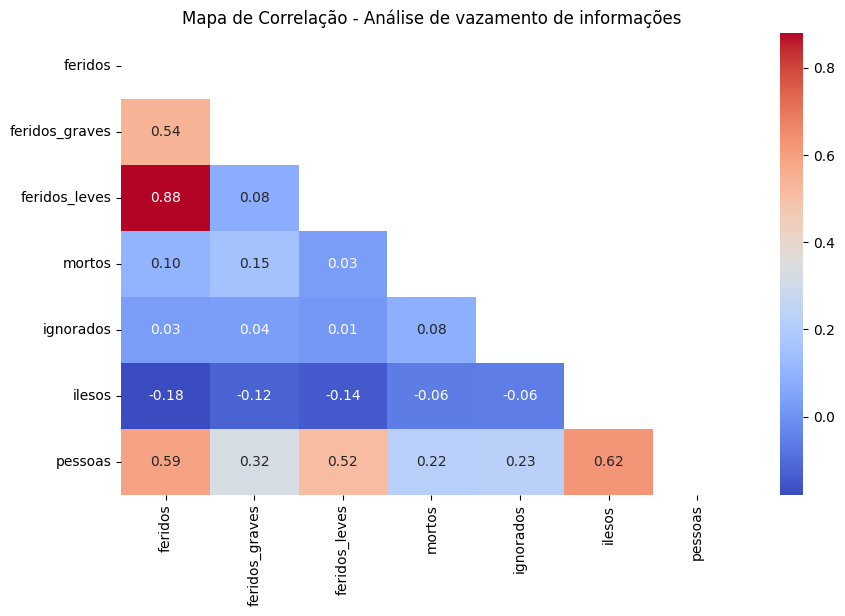

In [16]:
bases_vazamento_info = bases[['feridos','feridos_graves','feridos_leves','mortos','ignorados','ilesos','pessoas']].copy()

corr = bases_vazamento_info.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10,6))
sns.heatmap(corr, mask=mask, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Mapa de Correlação - Análise de vazamento de informações")
plt.show()

É possível notar a alta correlação entre as variáveis reforçando a necessidade de removê-las para o treinamento futuro evitando overfitting.

In [17]:
bases = remove_col(bases,['feridos_graves','feridos_leves','pessoas','ilesos','ignorados','mortos'])

### Tranformação das variáveis categóricas em numéricas

- Variáveis quantitativas ou métricas: são expressas em números que podem pertencer a intervalos discretos ou contínuos.

- Variáveis qualitativas ou categóricas: são expressas em um número finito de rótulos (categorias); podem ser nominais (sem ordenação) ou ordinais (com ordenação).

In [18]:
bases.select_dtypes(include='object').describe()

,uf,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,dia_semana
count,2194618,2194618,2194618,2194618,2194618,2194618,2194618,2194618,2194618,2194618,2194618,2194618
unique,27,2394,100,31,4,4,3,10,3,1328,4,7
top,MG,CURITIBA,Falta de atenção,Colisão traseira,Com Vítimas Feridas,pleno dia,Crescente,ceu claro,Simples,Reta,Urbano,sexta
freq,311635,29301,507384,553389,1043191,1255249,1136263,1131181,1134042,1495375,814640,352174


Observações:

* As variáveis categóricas nominais são: uf, municipio, causa_acidente, tipo_acidente,	classificacao_acidente, sentido_via,	condicao_metereologica, tipo_pista,	tracado_via, uso_solo	

* As variáveis categóricas ordinais: fase_dia

* As variáveis cíclicas: dia_semana, hora, dia, mes

**Variáveis categóricas nominais**

As variáveis do tipo uf e municipio já apresentam uma codificação padrão pelo IBGE. Logo vamos utilizá-la para substituir os valores encontrados na tabela pelos seus respectivos códigos.

In [19]:
bases['uf_mun'] = bases['uf'] + "-" + bases['municipio']

In [20]:
df_ibge = generate_file_ibge(os.path.join(ROOT,"contents\municipio_tse_ibge.csv"))

<>:1: SyntaxWarning: invalid escape sequence '\m'
<>:1: SyntaxWarning: invalid escape sequence '\m'
C:\Users\User\AppData\Local\Temp\ipykernel_23100\3602571416.py:1: SyntaxWarning: invalid escape sequence '\m'
  df_ibge = generate_file_ibge(os.path.join(ROOT,"contents\municipio_tse_ibge.csv"))


In [21]:
df_ibge.head()

,SG_UF,CD_UF_IBGE,CD_MUNICIPIO_IBGE,NM_MUNICIPIO_IBGE,municipio_norm,uf_mun
0,AC,12,1200138,BUJARI,BUJARI,AC-BUJARI
1,AC,12,1200179,CAPIXABA,CAPIXABA,AC-CAPIXABA
2,AC,12,1200807,PORTO ACRE,PORTO ACRE,AC-PORTO ACRE
3,AC,12,1200435,SANTA ROSA DO PURUS,SANTA ROSA DO PURUS,AC-SANTA ROSA DO PURUS
4,AC,12,1200351,MARECHAL THAUMATURGO,MARECHAL THAUMATURGO,AC-MARECHAL THAUMATURGO


*Adicionando a informação do código de UF*

In [22]:
# Adicionando o código referente a UF
lista_cod_uf = df_ibge[['SG_UF','CD_UF_IBGE']].copy()

lista_cod_uf = lista_cod_uf.drop_duplicates(keep='first')

In [23]:
bases.shape

(2194618, 22)

In [24]:
bases = bases.merge(lista_cod_uf,left_on='uf',right_on='SG_UF',how='left')

bases.shape

(2194618, 24)

In [25]:
bases.head(2)

,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,...,veiculos,data,ano,hora,mes,dia,dia_semana,uf_mun,SG_UF,CD_UF_IBGE
0,MG,40.0,585.5,ITABIRITO,Outras,Saída de Pista,Com Vítimas Feridas,pleno dia,Crescente,ceu claro,...,1,2007-08-13,2007,14,8,13,segunda,MG-ITABIRITO,MG,31
1,MA,135.0,11.0,SAO LUIS,Animais na Pista,Atropelamento de animal,Com Vítimas Fatais,plena noite,Crescente,ceu claro,...,1,2007-02-12,2007,2,2,12,segunda,MA-SAO LUIS,MA,21


In [26]:
bases['CD_UF_IBGE'].isnull().sum()

np.int64(0)

Para o código IBGE não tivemos valores sem correspondência.

*Adicionando a informação do código do município*

In [27]:
bases = bases.merge(df_ibge[['uf_mun','CD_MUNICIPIO_IBGE']], on='uf_mun',how='left')

bases.shape

(2194618, 25)

In [28]:
bases.head(3)

,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,...,data,ano,hora,mes,dia,dia_semana,uf_mun,SG_UF,CD_UF_IBGE,CD_MUNICIPIO_IBGE
0,MG,40.0,585.5,ITABIRITO,Outras,Saída de Pista,Com Vítimas Feridas,pleno dia,Crescente,ceu claro,...,2007-08-13,2007,14,8,13,segunda,MG-ITABIRITO,MG,31,3131901.0
1,MA,135.0,11.0,SAO LUIS,Animais na Pista,Atropelamento de animal,Com Vítimas Fatais,plena noite,Crescente,ceu claro,...,2007-02-12,2007,2,2,12,segunda,MA-SAO LUIS,MA,21,2111300.0
2,CE,222.0,30.8,CAUCAIA,Defeito mecânico em veículo,Capotamento,Com Vítimas Feridas,amanhecer,Decrescente,ceu claro,...,2007-11-20,2007,5,11,20,terca,CE-CAUCAIA,CE,23,2303709.0


In [29]:
bases = remove_col(bases,['SG_UF'])

In [30]:
bases.head(2)

,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,...,veiculos,data,ano,hora,mes,dia,dia_semana,uf_mun,CD_UF_IBGE,CD_MUNICIPIO_IBGE
0,MG,40.0,585.5,ITABIRITO,Outras,Saída de Pista,Com Vítimas Feridas,pleno dia,Crescente,ceu claro,...,1,2007-08-13,2007,14,8,13,segunda,MG-ITABIRITO,31,3131901.0
1,MA,135.0,11.0,SAO LUIS,Animais na Pista,Atropelamento de animal,Com Vítimas Fatais,plena noite,Crescente,ceu claro,...,1,2007-02-12,2007,2,2,12,segunda,MA-SAO LUIS,21,2111300.0


In [31]:
bases['CD_MUNICIPIO_IBGE'].isnull().sum()

np.int64(11967)

In [32]:
bases.shape

(2194618, 24)

Nem todos os municípios foram encontrados na base de substituição do código IBGE. Analisando qual a porcentagem que ele representa se removermos, seria aproximadamente 1% do total dos dados (11967/2194618 ~ 1%). Sendo assim vamos remover estes valores nulos do dataset.

Futuramente, podemos buscar normalizar os nomes dos municípios dependendo do comportamento do modelo.

In [33]:
bases.dropna(axis=0,inplace=True)

In [34]:
# Alterando o tipo da coluna de float para int
bases['CD_MUNICIPIO_IBGE'] = bases['CD_MUNICIPIO_IBGE'].astype('int64')

In [35]:
#Removendo as colunas que já foram transformadas
bases = remove_col(bases,['uf','municipio','uf_mun'])

Para as demais colunas, é possível notar que algumas apresentam alta cardinalidade. Sendo assim, aplicar a técnica de onehotencoding não seria ideal devido ao problema de dimensionalidade que a base apresentaria.

*baixa cardinalidade*
- classificacao_acidente
- sentido_via
- tipo_pista
- uso_solo

*alta cardinalidade*
- causa_acidente, 
- tipo_acidente
- condicao_metereologica,
- tracado_via

*Variáveis com baixa cardinalidade*

In [ ]:
colunas = ['classificacao_acidente','sentido_via','tipo_pista','uso_solo']
one_hot_enc = OneHotEncoder(sparse_output=False,handle_unknown='ignore')

encoded = one_hot_enc.fit_transform(bases[colunas])

In [37]:
df_encoded = pd.DataFrame(
    encoded,
    columns=one_hot_enc.get_feature_names_out(colunas),
    index=bases.index
)

bases_resultado = pd.concat([bases.drop(columns=colunas), df_encoded], axis=1)

In [38]:
bases_resultado.head(1)

,br,km,causa_acidente,tipo_acidente,fase_dia,condicao_metereologica,tracado_via,feridos,veiculos,data,...,sentido_via_Crescente,sentido_via_Decrescente,sentido_via_Não Informado,tipo_pista_Dupla,tipo_pista_Múltipla,tipo_pista_Simples,uso_solo_Não,uso_solo_Rural,uso_solo_Sim,uso_solo_Urbano
0,40.0,585.5,Outras,Saída de Pista,pleno dia,ceu claro,Reta,1,1,2007-08-13,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [39]:
bases_resultado.columns

Index(['br', 'km', 'causa_acidente', 'tipo_acidente', 'fase_dia',
       'condicao_metereologica', 'tracado_via', 'feridos', 'veiculos', 'data',
       'ano', 'hora', 'mes', 'dia', 'dia_semana', 'CD_UF_IBGE',
       'CD_MUNICIPIO_IBGE', 'classificacao_acidente_Com Vítimas Fatais',
       'classificacao_acidente_Com Vítimas Feridas',
       'classificacao_acidente_Ignorado', 'classificacao_acidente_Sem Vítimas',
       'sentido_via_Crescente', 'sentido_via_Decrescente',
       'sentido_via_Não Informado', 'tipo_pista_Dupla', 'tipo_pista_Múltipla',
       'tipo_pista_Simples', 'uso_solo_Não', 'uso_solo_Rural', 'uso_solo_Sim',
       'uso_solo_Urbano'],
      dtype='object')

*Variáveis com alta cardinalidade*

Técnica de codificação de frequência -> Substitui categoria pela frequência dela

In [40]:
colunas_freq = ['causa_acidente', 
'tipo_acidente','condicao_metereologica','tracado_via']

In [41]:
bases_resultado = codificacao_freq(bases_resultado,colunas_freq)

In [42]:
bases_resultado.head(1)

,br,km,causa_acidente,tipo_acidente,fase_dia,condicao_metereologica,tracado_via,feridos,veiculos,data,...,tipo_pista_Múltipla,tipo_pista_Simples,uso_solo_Não,uso_solo_Rural,uso_solo_Sim,uso_solo_Urbano,causa_acidente_freq,tipo_acidente_freq,condicao_metereologica_freq,tracado_via_freq
0,40.0,585.5,Outras,Saída de Pista,pleno dia,ceu claro,Reta,1,1,2007-08-13,...,0.0,1.0,0.0,1.0,0.0,0.0,449024,230929,1124644,1486976


In [43]:
bases_resultado.columns

Index(['br', 'km', 'causa_acidente', 'tipo_acidente', 'fase_dia',
       'condicao_metereologica', 'tracado_via', 'feridos', 'veiculos', 'data',
       'ano', 'hora', 'mes', 'dia', 'dia_semana', 'CD_UF_IBGE',
       'CD_MUNICIPIO_IBGE', 'classificacao_acidente_Com Vítimas Fatais',
       'classificacao_acidente_Com Vítimas Feridas',
       'classificacao_acidente_Ignorado', 'classificacao_acidente_Sem Vítimas',
       'sentido_via_Crescente', 'sentido_via_Decrescente',
       'sentido_via_Não Informado', 'tipo_pista_Dupla', 'tipo_pista_Múltipla',
       'tipo_pista_Simples', 'uso_solo_Não', 'uso_solo_Rural', 'uso_solo_Sim',
       'uso_solo_Urbano', 'causa_acidente_freq', 'tipo_acidente_freq',
       'condicao_metereologica_freq', 'tracado_via_freq'],
      dtype='object')

In [44]:
bases_resultado = remove_col(bases_resultado,col=['causa_acidente','tipo_acidente','condicao_metereologica','tracado_via'])

**Variáveis Cíclicas**

In [45]:
bases_resultado['dia_semana_num'] = bases_resultado['dia_semana'].map({
    'segunda':0,'terca':1,'quarta':2,
    'quinta':3,'sexta':4,'sabado':5,'domingo':6
})


bases_resultado = cod_ciclico(bases_resultado,'dia_semana_num',7)
bases_resultado = cod_ciclico(bases_resultado,'mes',12)
bases_resultado = cod_ciclico(bases_resultado,'hora',24)

In [46]:
bases_resultado.head(1)

,br,km,fase_dia,feridos,veiculos,data,ano,hora,mes,dia,...,tipo_acidente_freq,condicao_metereologica_freq,tracado_via_freq,dia_semana_num,dia_semana_num_sen,dia_semana_num_cos,mes_sen,mes_cos,hora_sen,hora_cos
0,40.0,585.5,pleno dia,1,1,2007-08-13,2007,14,8,13,...,230929,1124644,1486976,0,0.0,1.0,-0.866025,-0.5,-0.5,-0.866025


In [47]:
bases_resultado = remove_col(bases_resultado,['dia_semana_num','dia_semana','data'])

In [48]:
bases_resultado.columns

Index(['br', 'km', 'fase_dia', 'feridos', 'veiculos', 'ano', 'hora', 'mes',
       'dia', 'CD_UF_IBGE', 'CD_MUNICIPIO_IBGE',
       'classificacao_acidente_Com Vítimas Fatais',
       'classificacao_acidente_Com Vítimas Feridas',
       'classificacao_acidente_Ignorado', 'classificacao_acidente_Sem Vítimas',
       'sentido_via_Crescente', 'sentido_via_Decrescente',
       'sentido_via_Não Informado', 'tipo_pista_Dupla', 'tipo_pista_Múltipla',
       'tipo_pista_Simples', 'uso_solo_Não', 'uso_solo_Rural', 'uso_solo_Sim',
       'uso_solo_Urbano', 'causa_acidente_freq', 'tipo_acidente_freq',
       'condicao_metereologica_freq', 'tracado_via_freq', 'dia_semana_num_sen',
       'dia_semana_num_cos', 'mes_sen', 'mes_cos', 'hora_sen', 'hora_cos'],
      dtype='object')

**Variáveis Categóricas Ordinais**

In [49]:
# Definir a ordem correta das categorias
ordem = ['amanhecer', 'pleno dia', 'anoitecer','plena noite']

encoder = OrdinalEncoder(categories=[ordem])

# Aplicar a transformação
bases_resultado['fase_dia_encoded'] = encoder.fit_transform(bases_resultado[['fase_dia']])

In [50]:
# Removendo as colunas transformadas
bases_resultado = remove_col(bases_resultado,['fase_dia','hora','mes','dia'])

**Variáveis categóricas vistas como numéricas**

A variável km e br são numéricas mas não representam valores e sim localidades sobre o registro do acidente. Neste caso, elas não devem ser consideradas como numéricas para a entrada do modelo e sim como categóricas. Sendo assim, necessitam de uma transformação como as colunas anteriores.

Algumas abordagens podem ser utilizadas:

| Variável | Tipo real          | Melhor encoding         |
| -------- | ------------------ | ----------------------- |
| br       | categórica nominal | frequency / target      |
| km       | ordinal contextual | normalizar dentro da BR |
| br + km  | localização        | feature combinada       |

Como cada km está associada a uma br, irei criar uma nova coluna derivada da combinação das duas


In [51]:
bases_resultado['br_km'] = bases_resultado['br'].astype(str).str.strip() + "_" + bases_resultado['km'].astype(str).str.strip()

In [52]:
bases_resultado.head(3)

,br,km,feridos,veiculos,ano,CD_UF_IBGE,CD_MUNICIPIO_IBGE,classificacao_acidente_Com Vítimas Fatais,classificacao_acidente_Com Vítimas Feridas,classificacao_acidente_Ignorado,...,condicao_metereologica_freq,tracado_via_freq,dia_semana_num_sen,dia_semana_num_cos,mes_sen,mes_cos,hora_sen,hora_cos,fase_dia_encoded,br_km
0,40.0,585.5,1,1,2007,31,3131901,0.0,1.0,0.0,...,1124644,1486976,0.000000,1.00000,-0.866025,-0.500000,-0.500000,-0.866025,1.0,40.0_585.5
1,135.0,11.0,3,1,2007,21,2111300,1.0,0.0,0.0,...,1124644,1486976,0.000000,1.00000,0.866025,0.500000,0.500000,0.866025,3.0,135.0_11.0
2,222.0,30.8,1,1,2007,23,2303709,0.0,1.0,0.0,...,1124644,1486976,0.781831,0.62349,-0.500000,0.866025,0.965926,0.258819,0.0,222.0_30.8


In [53]:
bases_resultado = codificacao_freq_normal(bases_resultado,['br_km'])

In [54]:
#criando uma coluna referente ao posicionamento do km nas brs (é recomendada para a modelagem)
max_km_por_br = df.groupby('br', as_index=True)['km'].max()
bases_resultado['km_relativo'] = bases_resultado['km'] / max_km_por_br

In [55]:
bases_resultado.head(3)

,br,km,feridos,veiculos,ano,CD_UF_IBGE,CD_MUNICIPIO_IBGE,classificacao_acidente_Com Vítimas Fatais,classificacao_acidente_Com Vítimas Feridas,classificacao_acidente_Ignorado,...,tracado_via_freq,dia_semana_num_sen,dia_semana_num_cos,mes_sen,mes_cos,hora_sen,hora_cos,fase_dia_encoded,br_km_freq_normal,km_relativo
0,40.0,585.5,1,1,2007,31,3131901,0.0,1.0,0.0,...,1486976,0.000000,1.00000,-0.866025,-0.500000,-0.500000,-0.866025,1.0,0.0001,0.394515
1,135.0,11.0,3,1,2007,21,2111300,1.0,0.0,0.0,...,1486976,0.000000,1.00000,0.866025,0.500000,0.500000,0.866025,3.0,0.0001,0.065476
2,222.0,30.8,1,1,2007,23,2303709,0.0,1.0,0.0,...,1486976,0.781831,0.62349,-0.500000,0.866025,0.965926,0.258819,0.0,0.0001,0.076427


In [56]:
bases_resultado.columns

Index(['br', 'km', 'feridos', 'veiculos', 'ano', 'CD_UF_IBGE',
       'CD_MUNICIPIO_IBGE', 'classificacao_acidente_Com Vítimas Fatais',
       'classificacao_acidente_Com Vítimas Feridas',
       'classificacao_acidente_Ignorado', 'classificacao_acidente_Sem Vítimas',
       'sentido_via_Crescente', 'sentido_via_Decrescente',
       'sentido_via_Não Informado', 'tipo_pista_Dupla', 'tipo_pista_Múltipla',
       'tipo_pista_Simples', 'uso_solo_Não', 'uso_solo_Rural', 'uso_solo_Sim',
       'uso_solo_Urbano', 'causa_acidente_freq', 'tipo_acidente_freq',
       'condicao_metereologica_freq', 'tracado_via_freq', 'dia_semana_num_sen',
       'dia_semana_num_cos', 'mes_sen', 'mes_cos', 'hora_sen', 'hora_cos',
       'fase_dia_encoded', 'br_km_freq_normal', 'km_relativo'],
      dtype='object')

In [57]:
bases_resultado = remove_col(bases_resultado,['br','km'])

**Transformações das colunas**

* Variáveis categóricas

- *uf* -> CD_UF_IBGE
- *municipio* -> CD_MUNICIPIO_IBGE
- *classificacao_acidente* -> classificacao_acidente_Com Vítimas Fatais, classificacao_acidente_Com Vítimas Feridas,classificacao_acidente_Ignorado, classificacao_acidente_Sem Vítimas
- *sentido_via* -> sentido_via_Crescente, sentido_via_Decrescente, sentido_via_Não Informado
- *tipo_pista* ->  tipo_pista_Dupla, tipo_pista_Múltipla, tipo_pista_Simples
- *uso_solo* ->  uso_solo_Não, uso_solo_Rural , uso_solo_Sim, uso_solo_Urbano
- *causa_acidente* -> causa_acidente_freq
- *tipo_acidente* -> tipo_acidente_freq
- *condicao_meteorologica* -> condicao_meteorologica_freq
- *tracado_via* -> tracado_via_freq
- *br e km* -> br_km_freq_normal

* Variáveis Cíclicas:

- *hora* -> hora_sen, hora_cos
- *dia* -> dia_sen, dia_cos
- *mes* -> mes_sen, mes_cos

Logo, posso considerar a utilização destas colunas transformadas no modelo ao invés das originais.

### Análise de Correlação

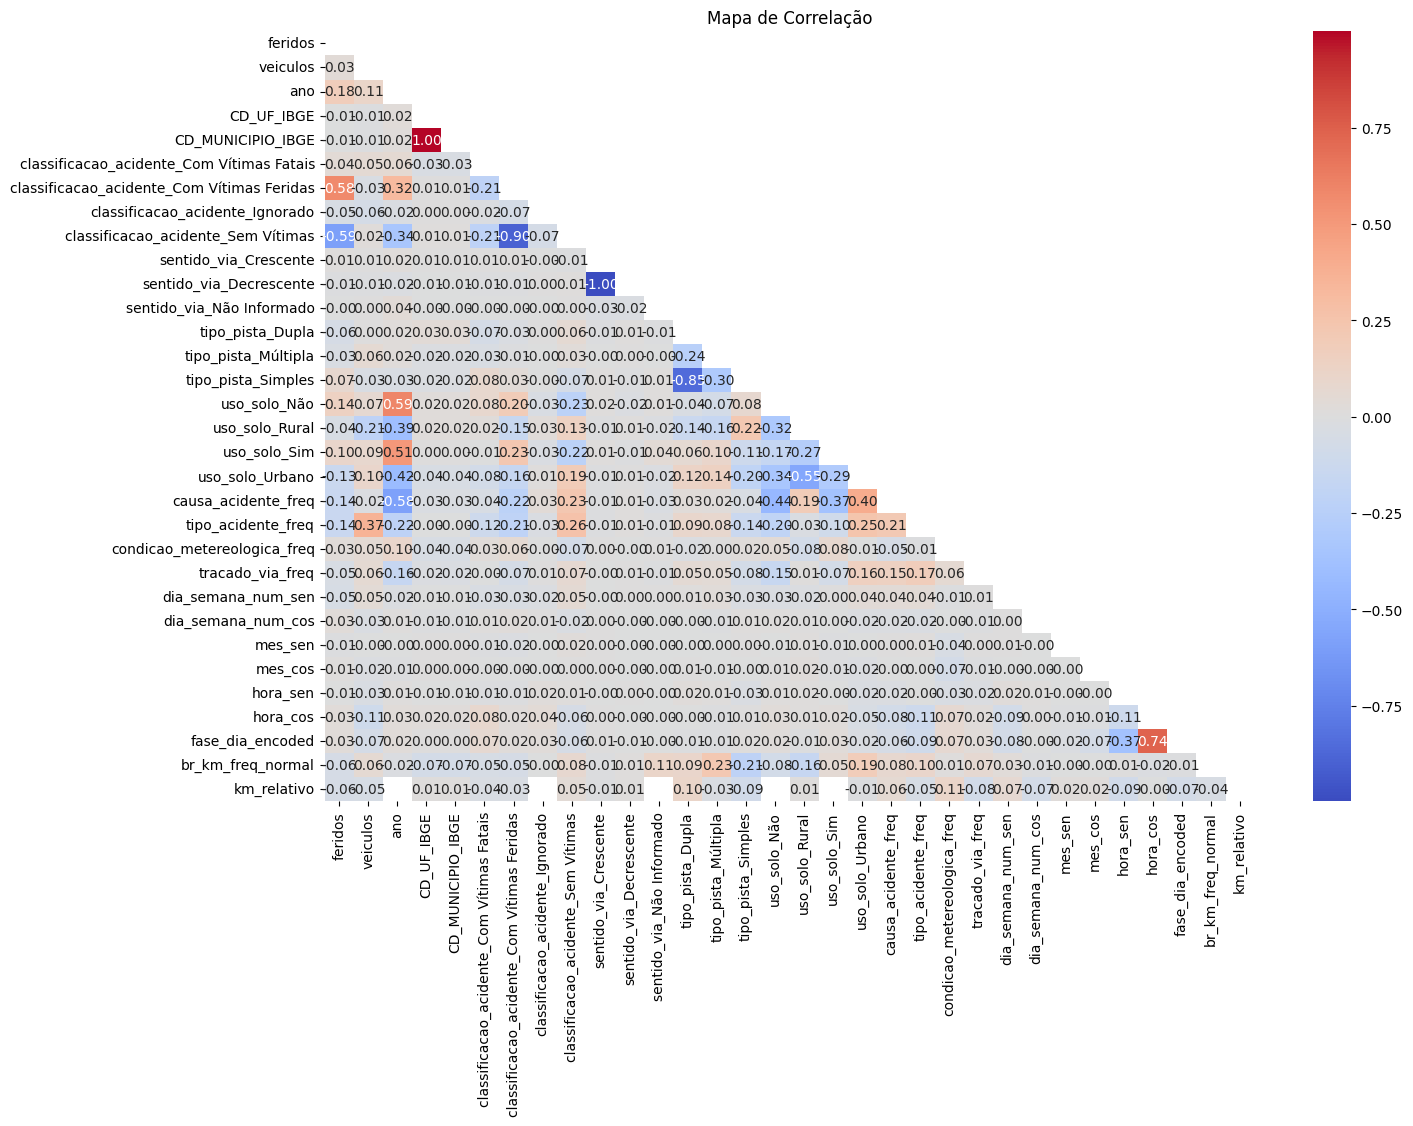

In [58]:
corr = bases_resultado.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(15,10))
sns.heatmap(corr, mask=mask, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Mapa de Correlação")
plt.show()

### Distribuição dos dados

In [59]:
bases_resultado.describe().round(0)

,feridos,veiculos,ano,CD_UF_IBGE,CD_MUNICIPIO_IBGE,classificacao_acidente_Com Vítimas Fatais,classificacao_acidente_Com Vítimas Feridas,classificacao_acidente_Ignorado,classificacao_acidente_Sem Vítimas,sentido_via_Crescente,...,tracado_via_freq,dia_semana_num_sen,dia_semana_num_cos,mes_sen,mes_cos,hora_sen,hora_cos,fase_dia_encoded,br_km_freq_normal,km_relativo
count,2182651.0,2182651.0,2182651.0,2182651.0,2182651.0,2182651.0,2182651.0,2182651.0,2182651.0,2182651.0,...,2182651.0,2182651.0,2182651.0,2182651.0,2182651.0,2182651.0,2182651.0,2182651.0,2182651.0,209.0
mean,1.0,2.0,2014.0,35.0,3485485.0,0.0,0.0,0.0,0.0,1.0,...,1102513.0,-0.0,-0.0,-0.0,0.0,-0.0,-0.0,2.0,0.0,7.0
std,1.0,1.0,5.0,9.0,946932.0,0.0,0.0,0.0,0.0,0.0,...,572105.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,30.0
min,0.0,1.0,2007.0,11.0,1100023.0,0.0,0.0,0.0,0.0,0.0,...,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0,0.0,0.0
25%,0.0,1.0,2010.0,29.0,2927408.0,0.0,0.0,0.0,0.0,0.0,...,428291.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,0.0,0.0
50%,0.0,2.0,2013.0,33.0,3303906.0,0.0,0.0,0.0,0.0,1.0,...,1486976.0,0.0,-0.0,-0.0,0.0,-0.0,-0.0,1.0,0.0,1.0
75%,1.0,2.0,2017.0,42.0,4207304.0,0.0,1.0,0.0,1.0,1.0,...,1486976.0,1.0,1.0,0.0,1.0,1.0,0.0,3.0,0.0,3.0
max,239.0,131.0,2025.0,53.0,5300108.0,1.0,1.0,1.0,1.0,1.0,...,1486976.0,1.0,1.0,1.0,1.0,1.0,1.0,3.0,0.0,262.0


### Geração da base para modelagem

In [60]:
export_sample(bases_resultado,1000)